In [14]:
import pandas as pd

file_path = "online_retail_II.xlsx"

df1 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
df2 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


**Basic Data Cleaning**


In [15]:
#Check missing values:
df.isnull().sum()


,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [16]:
#Remove rows without customer IDs:
df = df.dropna(subset=['Customer ID'])

In [17]:
#Remove returns/cancellations:
df = df[df['Quantity'] > 0]

In [18]:
#Remove invalid prices:
df = df[df['Price'] > 0]

In [19]:
print(df.shape)

(805549, 8)


**Create Revenue Column**

In [21]:
df['Revenue'] = df['Quantity'] * df['Price']

In [22]:
df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


**Convert Date Column**


In [23]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [24]:
#Find latest transaction date:
snapshot_date = df['InvoiceDate'].max()

print(snapshot_date)

2011-12-09 12:50:00


**Create RFM Features**

In [25]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

In [26]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [27]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,5633.32
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


**Exploratory Analysis**

In [28]:
#Top customers:
rfm.sort_values('Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary
Customer ID,,,
18102.0,0,145,608821.65
14646.0,1,151,528602.52
14156.0,9,156,313946.37
14911.0,0,398,295972.63
17450.0,7,51,246973.09
13694.0,3,143,196482.81
17511.0,2,60,175603.55
16446.0,0,2,168472.50
16684.0,3,55,147142.77


In [29]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,348.762500
50%,95.000000,3.000000,898.915000
75%,379.000000,7.000000,2307.090000
max,738.000000,398.000000,608821.650000


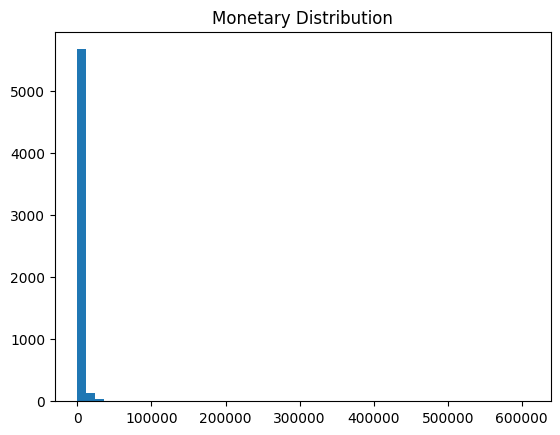

In [30]:
import matplotlib.pyplot as plt

plt.hist(rfm['Monetary'], bins=50)
plt.title("Monetary Distribution")
plt.show()

**Create Customer Segments**

In [31]:
rfm['Segment'] = pd.qcut(
    rfm['Monetary'],
    q=3,
    labels=['Low Value','Medium Value','High Value']
)

In [32]:
rfm['Segment'].value_counts()

,count
Segment,
Low Value,1960
High Value,1960
Medium Value,1958


**Random Forest:**

In [33]:
X = rfm[['Recency','Frequency']]
y = rfm['Monetary']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
pred = model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 :", r2_score(y_test, pred))

MAE: 2091.2511549473916
R2 : 0.5759777431286732


**Predict CLV**

In [38]:
rfm['Predicted_CLV'] = model.predict(
    rfm[['Recency','Frequency']]
)

In [39]:
rfm.to_csv(
    "clv_predictions.csv",
    index=True
)

In [43]:
def segment_customer(clv):
    if clv >= 10000:
        return "High Value"
    elif clv >= 3000:
        return "Medium Value"
    else:
        return "Low Value"

rfm['Segment'] = rfm['Predicted_CLV'].apply(segment_customer)

In [44]:
rfm['Segment'].value_counts()

,count
Segment,
Low Value,4677
Medium Value,906
High Value,295


In [45]:
rfm.to_csv("clv_predictions.csv")